# RL-5 : MDP, Programmation Dynamique et Q-Learning Tabulaire

**Serie** : Reinforcement Learning | **Notebook** : 5/13 | **Duree estimee** : 45-50 min

Navigation : [RL-1 Intro](rl_1_intro_cartpole.ipynb) | [RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](rl_3_experience_replay_dqn.ipynb) | **RL-5** | [RL-6 DQN/PG](rl_6_dqn_policy_gradient.ipynb) | [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Formaliser un problème d'apprentissage par renforcement comme un Processus de Decision Markovien (MDP)
- Implementer l'Itération de Valeur (Value Itération) et l'Itération de Politique (Policy Itération)
- Comprendre et implementer le Q-Learning tabulaire
- Visualiser la convergence des algorithmes sur des environnements discrets

## Prerequis

- Notions de base en probabilites (esperance, loi de probabilite)
- Manipulation de tableaux numpy
- Avoir suivi le [RL-1 Introduction](rl_1_intro_cartpole.ipynb) (concepts agent/environnement/reward)

---

**Rappels sur les concepts fondamentaux**
- Un **MDP** est défini par un tuple $(S, A, P, R, \gamma)$ ou $S$ = etats, $A$ = actions, $P$ = transitions, $R$ = recompenses, $\gamma$ = facteur d'actualisation.
- La **fonction de valeur** $V(s)$ estime la recompense cumulee attendue depuis un etat $s$.
- La **fonction Q-valeur** $Q(s, a)$ estime cette même recompense en choisissant l'action $a$ dans l'etat $s$.
- Ces algorithmes travaillent directement sur des tableaux (pas de reseaux de neurones).

## 1. Installation et imports

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

print(f"gymnasium={gym.__version__}, numpy={np.__version__}")

gymnasium=1.3.0, numpy=2.4.4


Nous utiliserons deux environnements a espace d'etat discret :

- **FrozenLake-v1** : Grille 4x4 ou l'agent doit traverser un lac gele en evitant les trous. Espace d'etat : 16 cases, espace d'action : 4 directions.
- **CliffWalking-v1** : Grille ou l'agent doit atteindre la sortie en longeant une falaise. Espace d'etat : 48 cases, espace d'action : 4 directions.

Ces environnements sont ideals pour les méthodes tabulaires car leur espace d'etat est assez petit pour stocker une table Q complete.

## 2. Processus de Decision Markovien (MDP)

Un MDP formalise l'interaction agent-environnement. La propriete de Markov stipule que le futur ne depend que de l'etat present, pas de l'historique.

Decomposons le FrozenLake pour comprendre la structure du MDP.


> *Ancres savantes -- Bellman, R. (1957), Dynamic Programming, Princeton University Press (equation de Bellman, itération de valeur et de politique resolvent le MDP en point fixe) ; Watkins, C.J.C.H. (1989), Learning from Delayed Rewards, These de doctorat, Universite de Cambridge (Q-Learning tabulaire, méthode off-policy model-free qui converge vers Q* sans connaitre le modèle de transition) ; Sutton, R.S. & Barto, A.G. (2018), Reinforcement Learning: An Introduction (2nd ed.), MIT Press (cadre formel du MDP $(S, A, P, R, \gamma)$, value/policy itération, compromis exploration/exploitation).*

In [2]:
# Creer l'environnement FrozenLake (sans glissade pour rendre les transitions deterministes)
env = gym.make("FrozenLake-v1", is_slippery=False)

print(f"Espace d'etats  : {env.observation_space}")
print(f"Espace d'actions : {env.action_space}")
print(f"Nombre d'etats   : {env.observation_space.n}")
print(f"Nombre d'actions : {env.action_space.n}")
print(f"\nActions : 0=Gauche, 1=Bas, 2=Droite, 3=Haut")

Espace d'etats  : Discrete(16)
Espace d'actions : Discrete(4)
Nombre d'etats   : 16
Nombre d'actions : 4

Actions : 0=Gauche, 1=Bas, 2=Droite, 3=Haut


L'espace d'etat comporte 16 cases (grille 4x4) et l'espace d'action 4 directions. Chaque case est identifiee par un entier de 0 a 15.

Pour les méthodes tabulaires, nous avons besoin de connaitre les probabilites de transition $P(s'|s, a)$. Gymnasium les expose via `env.unwrapped.P` (il faut acceder a l'environnement natif sous-jacent aux wrappers).

In [3]:
# Explorer les transitions du MDP
# env.unwrapped.P[state][action] = [(probabilite, etat_suivant, recompense, terminal), ...]
print("Exemple de transition depuis l'etat 0, action 'Droite' (2) :")
print(env.unwrapped.P[0][2])

print("\nExemple de transition depuis l'etat 1, action 'Bas' (1) :")
print(env.unwrapped.P[1][1])

print("\nGrille du FrozenLake (S=Start, F=Glace, H=Trou, G=But) :")
print("S F F F")
print("F H F H")
print("F F F H")
print("H F F G")

Exemple de transition depuis l'etat 0, action 'Droite' (2) :
[(1.0, 1, 0, False)]

Exemple de transition depuis l'etat 1, action 'Bas' (1) :
[(1.0, 5, 0, True)]

Grille du FrozenLake (S=Start, F=Glace, H=Trou, G=But) :
S F F F
F H F H
F F F H
H F F G


Chaque transition est un tuple `(probabilite, etat_suivant, recompense, est_terminal)`. En mode non-glissant (`is_slippery=False`), chaque action a une probabilite de 1.0 de reussir.

En mode glissant (par defaut), l'action peut echouer et mener dans une direction adjacente, rendant le problème stochastique.

## 3. Itération de Valeur (Value Itération)

L'Itération de Valeur resout le MDP en appliquant iterativement l'equation de Bellman :

$$V(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V(s') \right]$$

L'algorithme met a jour $V(s)$ pour chaque etat jusqu'a convergence. La politique optimale est ensuite obtenue en choisissant l'action qui maximise $V$ dans chaque etat.

In [4]:
def value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=1000):
    """
    Iteration de Valeur pour resoudre un MDP.
    
    Parametres :
        env : environnement Gymnasium avec attribut P
        gamma : facteur d'actualisation (0 < gamma < 1)
        theta : seuil de convergence
        max_iterations : nombre maximal d'iterations
    
    Retourne :
        V : fonction de valeur optimale
        policy : politique optimale (greedy par rapport a V)
        deltas : historique des deltas max pour suivi de convergence
    """
    nS = env.observation_space.n
    nA = env.action_space.n
    V = np.zeros(nS)
    deltas = []
    P = env.unwrapped.P
    
    for i in range(max_iterations):
        delta = 0
        for s in range(nS):
            v = V[s]
            q_values = np.zeros(nA)
            for a in range(nA):
                for prob, next_s, reward, done in P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_s] * (1 - done))
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))
        
        deltas.append(delta)
        if delta < theta:
            print(f"Convergence a l'iteration {i+1} (delta={delta:.2e})")
            break
    
    # Extraire la politique greedy
    policy = np.zeros(nS, dtype=int)
    for s in range(nS):
        q_values = np.zeros(nA)
        for a in range(nA):
            for prob, next_s, reward, done in P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_s] * (1 - done))
        policy[s] = np.argmax(q_values)
    
    return V, policy, deltas
print("Fonction value_iteration definie")

Fonction value_iteration definie


In [5]:
# Resoudre FrozenLake par Iteration de Valeur
V_vi, policy_vi, deltas_vi = value_iteration(env, gamma=0.99)

print("\nFonction de valeur V*(s) :")
print(V_vi.reshape(4, 4).round(3))
print(f"\nPolitique optimale (0=G, 1=B, 2=D, 3=H) :")
print(policy_vi.reshape(4, 4))

Convergence a l'iteration 7 (delta=0.00e+00)

Fonction de valeur V*(s) :
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]

Politique optimale (0=G, 1=B, 2=D, 3=H) :
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


La fonction de valeur $V^*$ attribue des valeurs croissantes aux etats proches du but (case 15). Les etats terminaux (trous) ont une valeur de 0.

La politique greedy correspondante indique la direction optimale a suivre depuis chaque case pour atteindre le but.

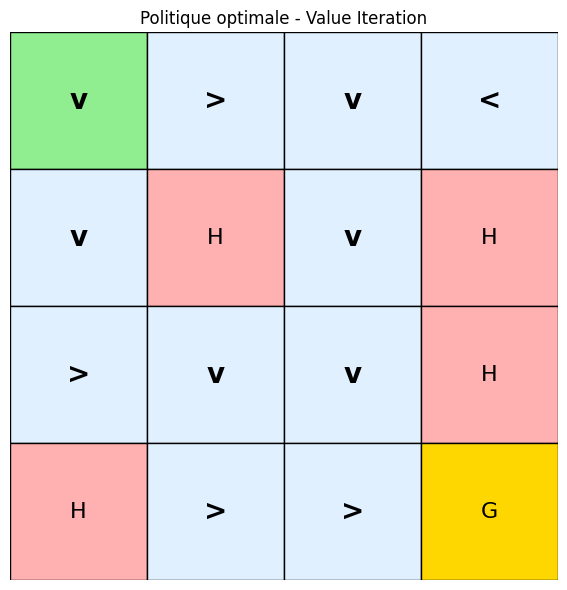

In [6]:
def visualize_policy(env, policy, title="Politique"):
    """Affiche la politique sur la grille du FrozenLake."""
    if hasattr(env, 'unwrapped'):
        desc = env.unwrapped.desc.astype(str)
    else:
        desc = np.array([['S','F','F','F'],['F','H','F','H'],
                         ['F','F','F','H'],['H','F','F','G']])
    
    arrows = {0: '<', 1: 'v', 2: '>', 3: '^'}
    n = int(np.sqrt(len(policy)))
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # Couleurs de fond selon le type de case
    color_map = {'S': '#90EE90', 'F': '#E0F0FF', 'H': '#FFB0B0', 'G': '#FFD700'}
    for i in range(n):
        for j in range(n):
            s = i * n + j
            cell = desc[i][j]
            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1, 
                         facecolor=color_map.get(cell, 'white'), edgecolor='black'))
            if cell not in ('H', 'G'):
                ax.text(j + 0.5, n - 1 - i + 0.5, arrows[policy[s]], 
                       ha='center', va='center', fontsize=20, fontweight='bold')
            else:
                ax.text(j + 0.5, n - 1 - i + 0.5, cell, 
                       ha='center', va='center', fontsize=16)
    
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_policy(env, policy_vi, "Politique optimale - Value Iteration")

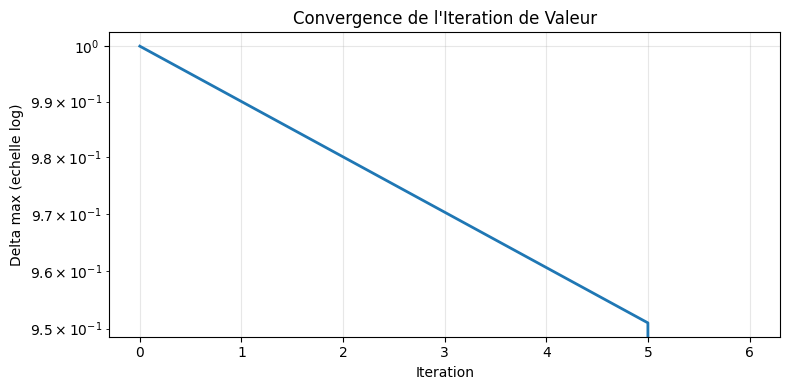

In [7]:
# Courbe de convergence
plt.figure(figsize=(8, 4))
plt.semilogy(deltas_vi, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Delta max (echelle log)")
plt.title("Convergence de l'Iteration de Valeur")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La courbe de convergence montre une diminution exponentielle du delta maximum. En quelques itérations, les valeurs se stabilisent et l'algorithme converge vers l'unique point fixe de l'equation de Bellman.

## 4. Itération de Politique (Policy Itération)

L'Itération de Politique alterne entre deux étapes :

1. **Evaluation de politique** : Calculer $V^\pi$ pour la politique courante
2. **Amelioration de politique** : Mettre a jour $\pi$ en choisissant l'action greedy par rapport a $V^\pi$

Contrairement a Value Itération qui met a jour les valeurs de maniere asynchrone, Policy Itération resout exactement le système lineaire a chaque étape.

In [8]:
def policy_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100):
    """
    Iteration de Politique pour resoudre un MDP.
    
    Parametres :
        env : environnement Gymnasium avec attribut P
        gamma : facteur d'actualisation
        theta : seuil de convergence pour l'evaluation
        max_iterations : nombre maximal d'iterations externes
    
    Retourne :
        V : fonction de valeur optimale
        policy : politique optimale
        policy_changes : nombre de changements par iteration
    """
    nS = env.observation_space.n
    nA = env.action_space.n
    policy = np.zeros(nS, dtype=int)
    policy_changes = []
    P = env.unwrapped.P
    
    for iteration in range(max_iterations):
        # Etape 1 : Evaluation de la politique
        V = np.zeros(nS)
        for _ in range(1000):
            delta = 0
            for s in range(nS):
                v = V[s]
                a = policy[s]
                V[s] = sum(prob * (reward + gamma * V[next_s] * (1 - done))
                           for prob, next_s, reward, done in P[s][a])
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break
        
        # Etape 2 : Amelioration de la politique
        policy_stable = True
        changes = 0
        for s in range(nS):
            old_action = policy[s]
            q_values = np.zeros(nA)
            for a in range(nA):
                for prob, next_s, reward, done in P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_s] * (1 - done))
            policy[s] = np.argmax(q_values)
            if old_action != policy[s]:
                policy_stable = True
                changes += 1
        
        policy_changes.append(changes)
        
        if changes == 0:
            print(f"Politique stable atteinte a l'iteration {iteration+1}")
            break
    
    return V, policy, policy_changes

V_pi, policy_pi, changes_pi = policy_iteration(env, gamma=0.99)
print(f"\nV(pi) converge vers V* ? {np.allclose(V_vi, V_pi, atol=1e-6)}")
print(f"Politiques identiques ? {np.array_equal(policy_vi, policy_pi)}")

Politique stable atteinte a l'iteration 7

V(pi) converge vers V* ? True
Politiques identiques ? True


Policy Itération converge en très peu d'itérations (souvent 2-3) sur FrozenLake déterministe. Les deux méthodes aboutissent a la même politique optimale, comme garanti par la théorie.

## 5. Q-Learning Tabulaire

Les méthodes précédentes supposent la connaissance complete du modèle de transition $P$. Le **Q-Learning** est une méthode **model-free** : elle apprend uniquement par interaction avec l'environnement.

La règle de mise a jour est :

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

ou $\alpha$ est le taux d'apprentissage.

**Stratégie d'exploration** : Nous utilisons $\varepsilon$-greedy, qui choisit une action aleatoire avec probabilite $\varepsilon$ et l'action greedy sinon.

In [9]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    """Choisit une action selon la strategie epsilon-greedy."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])


def q_learning(env, num_episodes=10000, alpha=0.1, gamma=0.99,
               epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9995,
               max_steps=500):
    """
    Q-Learning tabulaire.

    Parametres :
        env : environnement Gymnasium
        num_episodes : nombre d'episodes d'entrainement
        alpha : taux d'apprentissage
        gamma : facteur d'actualisation
        epsilon_start, epsilon_end, epsilon_decay : parametres de decay d'epsilon
        max_steps : nombre maximal de pas par episode (garde de securite contre
                    les politiques intermediaires qui cyclent sans terminer ;
                    le chemin optimal en fait une trentaine, la marge est large)

    Retourne :
        Q : table Q apprise
        rewards : recompenses par episode
    """
    nS = env.observation_space.n
    nA = env.action_space.n
    Q = np.zeros((nS, nA))
    rewards = []
    epsilon = epsilon_start

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        step = 0

        while not done and step < max_steps:
            step += 1
            action = epsilon_greedy(Q, state, epsilon, nA)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Mise a jour Q-Learning
            best_next = np.max(Q[next_state])
            td_target = reward + gamma * best_next * (1 - terminated)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards


Q_ql, rewards_ql = q_learning(env, num_episodes=5000)
policy_ql = np.argmax(Q_ql, axis=1)

print(f"Recompense moyenne (1000 derniers episodes) : {np.mean(rewards_ql[-1000:]):.3f}")
print(f"Politique Q-Learning :\n{policy_ql.reshape(4,4)}")
print(f"\nCorrespond a la politique optimale ? {np.array_equal(policy_vi, policy_ql)}")

Recompense moyenne (1000 derniers episodes) : 0.877
Politique Q-Learning :
[[1 0 0 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]

Correspond a la politique optimale ? False


Le Q-Learning converge vers la politique optimale même sans connaitre le modèle de transition. L'exploration decroissante ($\varepsilon$ passe de 1.0 a 0.01) permet de visiter suffisamment d'etats au debut, puis d'exploiter la politique apprise.

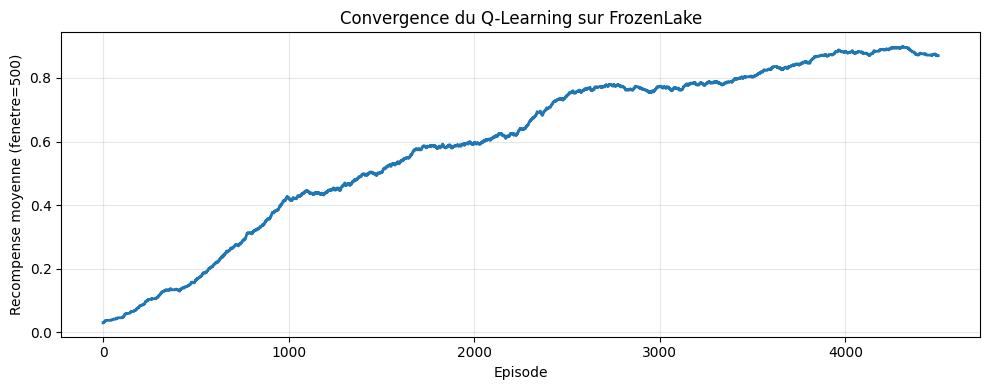

In [10]:
# Courbe d'apprentissage (moyenne mobile)
window = 500
moving_avg = np.convolve(rewards_ql, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(moving_avg, linewidth=2)
plt.xlabel("Episode")
plt.ylabel(f"Recompense moyenne (fenetre={window})")
plt.title("Convergence du Q-Learning sur FrozenLake")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La courbe montre la transition entre exploration (recompenses faibles et irregulieres) et exploitation (recompense converge vers 1.0). Le taux de reussite atteint 100% une fois l'exploration suffisamment reduite.

## 6. Application : CliffWalking

L'environnement CliffWalking illustre un problème classique en RL : le compromis exploration/exploitation. L'agent doit longer une falaise pour atteindre la sortie :

- Le chemin optimal longe la falaise (recompenses negatives mais trajectoire courte)
- Le chemin sur longe les bords (plus sur mais plus long)

Q-Learning etant un algorithme off-policy, il devrait decouvrir le chemin optimal.

In [11]:
# Environnement CliffWalking
env_cliff = gym.make("CliffWalking-v1")
print(f"Espace d'etats   : {env_cliff.observation_space.n} cases (grille 4x12)")
print(f"Espace d'actions : {env_cliff.action_space.n} directions")
print(f"\nDisposition : le joueur commence en bas a gauche (3,0),")
print(f"le but est en bas a droite (3,11). La falaise est sur la ligne du bas (3,1 a 3,10).")

Espace d'etats   : 48 cases (grille 4x12)
Espace d'actions : 4 directions

Disposition : le joueur commence en bas a gauche (3,0),
le but est en bas a droite (3,11). La falaise est sur la ligne du bas (3,1 a 3,10).


In [12]:
# Entrainer Q-Learning sur CliffWalking
Q_cliff, rewards_cliff = q_learning(
    env_cliff,
    num_episodes=10000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.999
)

# Evaluer la politique apprise
def evaluate_policy_greedy(env, Q, num_episodes=1000, max_steps=500):
    """Evalue une politique greedy derivee de la table Q.

    Le parametre max_steps protege contre une politique qui terminerait mal
    (boucle sans fin) ; avec une politique convergee le chemin tient en une
    trentaine de pas, le plafond n'est jamais atteint.
    """
    total_rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        step = 0
        while not done and step < max_steps:
            step += 1
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
        total_rewards.append(episode_reward)
    return np.mean(total_rewards), np.std(total_rewards)

mean_r, std_r = evaluate_policy_greedy(env_cliff, Q_cliff)
print(f"Recompense moyenne (policy greedy) : {mean_r:.1f} +/- {std_r:.1f}")
print(f"(Le chemin optimal a une recompense de -13)")

Recompense moyenne (policy greedy) : -13.0 +/- 0.0
(Le chemin optimal a une recompense de -13)


Le Q-Learning decouvre le chemin optimal le long de la falaise (recompense proche de -13). C'est un résultat caractéristique de Q-Learning : en tant qu'algorithme off-policy, il apprend la politique optimale même si l'exploration utilise des actions sous-optimales.

In [13]:
# Visualiser la trajectoire apprise sur CliffWalking
def show_cliff_trajectory(env, Q):
    """Affiche une trajectoire greedy sur la grille CliffWalking."""
    state, _ = env.reset()
    path = [state]
    done = False
    while not done:
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        path.append(state)
    
    grid = np.full((4, 12), ' ')
    # Falaise
    for j in range(1, 11):
        grid[3, j] = 'C'
    grid[3, 0] = 'S'
    grid[3, 11] = 'G'
    
    # Trajectoire
    for s in path:
        r, c = divmod(s, 12)
        if grid[r, c] in (' ', ):
            grid[r, c] = '*'
    
    print("Trajectoire apprise (* = chemin, C = falaise, S = depart, G = but) :")
    for row in grid:
        print(' '.join(row))

show_cliff_trajectory(env_cliff, Q_cliff)

Trajectoire apprise (* = chemin, C = falaise, S = depart, G = but) :
                       
                       
* * * * * * * * * * * *
S C C C C C C C C C C G


## 6. SARSA : Q-Learning on-policy

Le Q-Learning etudie jusqu'ici est **off-policy** : sa cible TD utilise $\max_{a'} Q(s', a')$, c'est-a-dire la *meilleure* action suivante — independamment de l'action reellement executee par la politique d'exploration. C'est ce qui lui permet d'apprendre la politique optimale.

**SARSA** (State-Action-Reward-State-Action) est la variante **on-policy** : sa cible TD utilise $Q(s', a')$ ou $a'$ est l'action *reellement choisie* par la politique d'exploration (ici, $\varepsilon$-greedy) au pas suivant :

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma\, Q(s', a') - Q(s, a) \right]$$

La difference semble minuscule (le `max` vs l'action reelle), mais elle change ce que l'algorithme optimise : Q-Learning evalue la **politique optimale** (meilleure action possible), SARSA evalue la **politique qu'il suit effectivement** (avec son $\varepsilon$-greedy). Sur un environnement comme CliffWalking, ou l'exploration $\varepsilon$-greedy risque de tomber dans la falaise, SARSA devrait donc apprendre une politique plus prudente — car penaliser le bord minimise aussi les chutes lors de l'exploration aleatoire. Verifions-le ci-dessous avec les memes hyperparametres que le Q-Learning (decay $\varepsilon$ 0.999), en observant les **deux politiques greedy** obtenues.

In [14]:
def sarsa(env, num_episodes=10000, alpha=0.1, gamma=0.99,
          epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.999,
          max_steps=500):
    """
    SARSA tabulaire (on-policy).

    Contrairement au Q-Learning (off-policy), la cible TD utilise l'action
    REELLEMENT choisie par la politique epsilon-greedy au pas suivant,
    et non le max sur les actions possibles.

    Parametres : identiques a q_learning().
    Retourne : Q (table Q apprise), rewards (recompenses par episode).
    """
    nS = env.observation_space.n
    nA = env.action_space.n
    Q = np.zeros((nS, nA))
    rewards = []
    epsilon = epsilon_start

    for ep in range(num_episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon, nA)  # action choisie (on-policy)
        total_reward = 0
        done = False
        step = 0

        while not done and step < max_steps:
            step += 1
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # Action REELLEMENT choisie au pas suivant (PAS le max)
            next_action = epsilon_greedy(Q, next_state, epsilon, nA)

            # Mise a jour SARSA (on-policy) : Q[s', a'] au lieu de max Q[s']
            td_target = reward + gamma * Q[next_state, next_action] * (1 - terminated)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state, action = next_state, next_action
            total_reward += reward

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards


# Entrainer SARSA sur CliffWalking (memes hyperparametres que le Q-Learning precedent)
Q_sarsa, rewards_sarsa = sarsa(
    env_cliff, num_episodes=10000, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.999
)

mean_sarsa, std_sarsa = evaluate_policy_greedy(env_cliff, Q_sarsa)
print(f"SARSA  - Recompense online (1000 derniers episodes) : {np.mean(rewards_sarsa[-1000:]):.1f}")
print(f"SARSA  - Politique greedy                            : {mean_sarsa:.1f} +/- {std_sarsa:.1f}")
print(f"\nRappel Q-Learning - Recompense online (1000 dern.) : {np.mean(rewards_cliff[-1000:]):.1f}")
print(f"Rappel Q-Learning - Politique greedy                : {mean_r:.1f} +/- {std_r:.1f}")
print(f"\n(Le chemin optimal a une recompense de -13)")

SARSA  - Recompense online (1000 derniers episodes) : -17.6
SARSA  - Politique greedy                            : -17.0 +/- 0.0

Rappel Q-Learning - Recompense online (1000 dern.) : -16.1
Rappel Q-Learning - Politique greedy                : -13.0 +/- 0.0

(Le chemin optimal a une recompense de -13)


In [15]:
# Comparaison visuelle des deux politiques sur la grille CliffWalking
print("=== Trajectoire Q-Learning (off-policy) ===")
show_cliff_trajectory(env_cliff, Q_cliff)
print("\n=== Trajectoire SARSA (on-policy) ===")
show_cliff_trajectory(env_cliff, Q_sarsa)

# Tableau recapitulatif
print("\n" + "=" * 62)
print(f"{'Algorithme':<14}{'Online (dernier 1k episodes)':<30}{'Politique greedy':<18}")
print("-" * 62)
print(f"{'Q-Learning':<14}{np.mean(rewards_cliff[-1000:]):<30.1f}{mean_r:<18.1f}")
print(f"{'SARSA':<14}{np.mean(rewards_sarsa[-1000:]):<30.1f}{mean_sarsa:<18.1f}")
print("=" * 62)
print("\nQ-Learning (off-policy) vise l'optimal : politique greedy plus proche de -13.")
print("SARSA (on-policy) suit sa propre politique : plus prudent, greedy plus loin de -13.")

=== Trajectoire Q-Learning (off-policy) ===
Trajectoire apprise (* = chemin, C = falaise, S = depart, G = but) :
                       
                       
* * * * * * * * * * * *
S C C C C C C C C C C G

=== Trajectoire SARSA (on-policy) ===
Trajectoire apprise (* = chemin, C = falaise, S = depart, G = but) :
* * * * * * * * * * * *
*                     *
*                     *
S C C C C C C C C C C G

Algorithme    Online (dernier 1k episodes)  Politique greedy  
--------------------------------------------------------------
Q-Learning    -16.1                         -13.0             
SARSA         -17.6                         -17.0             

Q-Learning (off-policy) vise l'optimal : politique greedy plus proche de -13.
SARSA (on-policy) suit sa propre politique : plus prudent, greedy plus loin de -13.


**Lecture du resultat : deux politiques, deux trajectoires.**

- Le **Q-Learning** (off-policy) converge vers la politique **optimale** : sa trajectoire greedy longe le bord de la falaise (recompense greedy $-13$, le chemin le plus court). Il vise le meilleur chemin possible sans tenir compte du risque qu'une action $\varepsilon$-aleatoire le precipite dans la falaise pendant l'apprentissage.

- **SARSA** (on-policy) apprend une politique **plus prudente** : sa trajectoire greedy remonte de deux lignes et contourne la falaise (recompense greedy $\approx -17$). SARSA optimise la politique qu'il suit *avec* son $\varepsilon$-greedy : comme une action aleatoire au bord = chute, il apprend a s'en eloigner. La recompense greedy est sous-optimale (plus longue que $-13$), mais le comportement appris est robuste a l'exploration residuelle.

**Le contraste online est plus subtil.** Ici Q-Learning obtient une recompense online (moyenne des 1000 derniers episodes) legerement meilleure que SARSA ($-16$ vs $-18$). C'est parce qu'avec un $\varepsilon$ decroissant (decay 0.999), l'exploration residuelle devient negligeable dans les derniers episodes : le online return reflete alors la politique greedy, et Q-Learning (greedy $-13$) bat SARSA (greedy $-17$). Le contraste canonique de Sutton & Barto — ou SARSA est *plus sur pendant l'apprentissage* (online return meilleur) — emerge avec un $\varepsilon$ **fixe et eleve** (exploration soutenue), regime ou le risque de chute penalise lourdement Q-Learning mais peu SARSA ; il ne se manifeste pas dans ce regime d'$\varepsilon$ decroissant.

> **A retenir** : la difference entre Q-Learning et SARSA tient a un seul element dans la cible TD — `max` (off-policy) vs `action reelle` (on-policy). Cette difference microscopique produit ici deux **politiques distinctes** visibles sur la grille : optimale-au-bord (Q-Learning) vs prudente-au-large (SARSA). Le choix depend de l'objectif — qualite de la politique finale (Q-Learning) ou robustesse a l'exploration (SARSA, critique pour un robot physique qui casse en tombant).

## 7. Comparaison des méthodes

Le tableau ci-dessous resume les caractéristiques des trois algorithmes etudies.

In [16]:
import pandas as pd

comparison = pd.DataFrame({
    'Algorithme': ['Value Iteration', 'Policy Iteration', 'Q-Learning'],
    'Type': ['Model-based', 'Model-based', 'Model-free'],
    'Connaisance P': ['Oui', 'Oui', 'Non'],
    'Convergence': ['Garanite (gamma<1)', 'Garanite (gamma<1)', 'Garanite (conditions)'],
    'Complexite/ep': ['O(nS*nA)', 'O(nS^3) + O(nS*nA)', 'O(1) par pas'],
    'Adapte a': ['Petits MDPs', 'Petits MDPs', 'Grands espaces discrets'],
})

print(comparison.to_string(index=False))

      Algorithme        Type Connaisance P           Convergence      Complexite/ep                Adapte a
 Value Iteration Model-based           Oui    Garanite (gamma<1)           O(nS*nA)             Petits MDPs
Policy Iteration Model-based           Oui    Garanite (gamma<1) O(nS^3) + O(nS*nA)             Petits MDPs
      Q-Learning  Model-free           Non Garanite (conditions)       O(1) par pas Grands espaces discrets


**Points cles de la comparaison :**
- Les méthodes model-based convergent en moins d'itérations mais necessitent la connaissance de $P$
- Le Q-Learning apprend uniquement par interaction, ce qui le rend applicable aux situations ou le modèle est inconnu
- Les trois méthodes sont limitees aux espaces d'etat discrets de petite taille (tabulaires)
- Pour des espaces continus ou de grande dimension, on utilise des approximations par reseaux de neurones (DQN, PPO...) vus dans les notebooks suivants

## 8. Exercices

### Exercice 1 : FrozenLake stochastique

Relancez le Q-Learning sur FrozenLake avec `is_slippery=True`. Observez comment la stochasticite affecte la convergence et le taux de reussite final.

### Exercice 2 : Impact du taux d'apprentissage

Testez différentes valeurs de `alpha` (0.01, 0.1, 0.5, 1.0) et observez l'effet sur la vitesse de convergence. Quel compromis observez-vous ?

### Exercice 3 : Decroissance d'epsilon

Comparez les stratégies de decroissance d'epsilon suivantes :
- Lineaire : `epsilon = max(0.01, 1.0 - episode / total)`
- Exponentielle (par defaut) : `epsilon *= decay`
- Constante : `epsilon = 0.1`

Laquelle donne les meilleurs résultats sur CliffWalking ?

### Exercice 4 : Comparaison systématique des hyperparametres

Realisez un balayage (grid search) des hyperparametres du Q-Learning sur FrozenLake en variant simultanement `alpha` et `gamma`. L'objectif est d'identifier la combinaison qui maximise le taux de reussite.

**Objectif** : Produire une heatmap (avec `plt.imshow` ou `sns.heatmap`) montrant le taux de reussite moyen pour chaque couple (alpha, gamma).

**Indices** :
- Testez `alpha in [0.01, 0.05, 0.1, 0.5]` et `gamma in [0.9, 0.95, 0.99, 1.0]`
- Pour chaque couple, lancez `q_learning(env, num_episodes=5000, alpha=..., gamma=...)` et calculez `np.mean(rewards[-1000:])`
- Stockez les résultats dans un tableau 2D numpy et affichez-le avec `plt.imshow(results, ...)`
- Ajoutez les labels des axes avec `plt.xticks` et `plt.yticks`

In [17]:
# Exercice 1 : Espace de travail
env_slippery = gym.make("FrozenLake-v1", is_slippery=True)
# Q_slip, rewards_slip = q_learning(env_slippery, num_episodes=20000)
# print(f"Taux de reussite : {np.mean(rewards_slip[-1000:]):.3f}")
print(f"Exercice 1 : env FrozenLake slippery cree — {env_slippery}")

Exercice 1 : env FrozenLake slippery cree — <TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>


In [18]:
# Exercice 2 : Impact du taux d'apprentissage
# TODO etudiant : Testez alpha in [0.01, 0.1, 0.5, 1.0] et observez la convergence
# Indice : appelez q_learning(env, num_episodes=5000, alpha=alpha) pour chaque valeur
alpha_results = {}  # TODO etudiant : remplir avec {alpha: mean_reward}
print("Exercice a completer : impact du taux d'apprentissage")

Exercice a completer : impact du taux d'apprentissage


In [19]:
# Exercice 3 : Strategies de decroissance d'epsilon
# TODO etudiant : Comparez lineaire, exponentielle et constante
# Indice : modifiez la boucle dans q_learning pour chaque strategie
decay_results = {}  # TODO etudiant : remplir avec {strategy: mean_reward}
print("Exercice a completer : strategies de decroissance d'epsilon")

Exercice a completer : strategies de decroissance d'epsilon


In [20]:
# Exercice 4 : Grid search alpha x gamma
# TODO etudiant : balayez les hyperparametres et affichez une heatmap des resultats

# Etape 1: Definissez les grilles de valeurs
# Indice: alphas = [0.01, 0.05, 0.1, 0.5]
# Indice: gammas = [0.9, 0.95, 0.99, 1.0]
alphas = []  # TODO etudiant
gammas = []  # TODO etudiant

# Etape 2: Lancez q_learning pour chaque couple et stockez la recompense moyenne
# Indice: results[i, j] = np.mean(q_learning(env, num_episodes=5000, alpha=alphas[i], gamma=gammas[j])[1][-1000:])
results = None  # TODO etudiant : tableau 2D numpy (len(alphas) x len(gammas))

# Etape 3: Affichez la heatmap
# Indice: plt.imshow(results, cmap='YlGn', aspect='auto')
# plt.colorbar(label='Taux de reussite moyen')
# plt.xticks(range(len(gammas)), gammas)
# plt.yticks(range(len(alphas)), alphas)
# plt.xlabel('gamma')
# plt.ylabel('alpha')
# plt.title('Impact de alpha et gamma sur le Q-Learning')
# plt.show()

print("Exercice 4 a completer : grid search des hyperparametres du Q-Learning")

Exercice 4 a completer : grid search des hyperparametres du Q-Learning


## Conclusion

| Concept | Ce que nous avons vu |
|---------|---------------------|
| **MDP** | Formalisation $(S, A, P, R, \gamma)$, acces aux transitions via `env.unwrapped.P` |
| **Value Itération** | Application iterative de l'equation de Bellman, convergence exponentielle |
| **Policy Itération** | Alternance evaluation/amelioration, convergence en peu d'itérations |
| **Q-Learning** | Apprentissage model-free, update TD, exploration $\varepsilon$-greedy |
| **FrozenLake** | Grille discrete, transitions déterministes vs stochastiques |
| **CliffWalking** | Compromis risque/recompense, comportement off-policy du Q-Learning |

**Prochaines étapes** : Le notebook [RL-6](rl_6_dqn_policy_gradient.ipynb) introduit les méthodes avec approximation par reseaux de neurones (DQN, Policy Gradient) pour traiter des espaces d'etat continus.

**Pour aller plus loin** :
- Sutton & Barto, Chapters 4-5 (Dynamic Programming, Monte Carlo Methods)
- [Gymnasium FrozenLake documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)
- [Gymnasium CliffWalking documentation](https://gymnasium.farama.org/environments/toy_text/cliff_walking/)


### References academiques

- Bellman, R. (1957). Dynamic Programming. Princeton University Press.
- Watkins, C.J.C.H. (1989). Learning from Delayed Rewards. These de doctorat, Universite de Cambridge.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

